In [1]:
# ── Cell 1: Loading all three processed datasets ─────────────────────
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

df_credit = pd.read_csv('../data/processed/rbi_msme_credit.csv')
df_npa    = pd.read_csv('../data/processed/rbi_npa.csv')
df_cgtmse = pd.read_csv('../data/processed/cgtmse_guarantees.csv')

print("Credit data years:", df_credit['fiscal_year'].tolist())
print("NPA data years:", df_npa['fiscal_year'].tolist())
print("CGTMSE data years:", df_cgtmse['fiscal_year'].tolist())

Credit data years: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
NPA data years: ['2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
CGTMSE data years: ['FY 2019-20', 'FY 2020-21', 'FY 2021-22', 'FY 2022-23', 'FY 2023-24', 'FY 2024-25']


In [2]:
# ── Cell 2: Finding overlapping years across all 3 pillars ───────────
# CGTMSE uses "FY 2020-21" format — standardize to match RBI "2020-21"
df_cgtmse['fiscal_year_clean'] = df_cgtmse['fiscal_year'].str.replace('FY ', '')

credit_years  = set(df_credit['fiscal_year'])
npa_years     = set(df_npa['fiscal_year'])
cgtmse_years  = set(df_cgtmse['fiscal_year_clean'])

overlap = credit_years & npa_years & cgtmse_years
print(f"Overlapping years for composite index: {sorted(overlap)}")

Overlapping years for composite index: ['2020-21', '2021-22', '2022-23', '2023-24']


In [3]:
# ── Cell 3: Build master dataset for overlapping years ────────────
df_master = df_credit[df_credit['fiscal_year'].isin(overlap)][
    ['fiscal_year', 'msme_credit_growth_pct']
].copy()

df_npa_overlap = df_npa[df_npa['fiscal_year'].isin(overlap)][
    ['fiscal_year', 'gross_npa_pct']
]

df_cgtmse_overlap = df_cgtmse[
    df_cgtmse['fiscal_year_clean'].isin(overlap)
][['fiscal_year_clean', 'guarantee_growth_pct']].rename(
    columns={'fiscal_year_clean': 'fiscal_year'}
)

df_master = df_master.merge(df_npa_overlap, on='fiscal_year')
df_master = df_master.merge(df_cgtmse_overlap, on='fiscal_year')
df_master = df_master.dropna().sort_values('fiscal_year').reset_index(drop=True)

print("\nMaster dataset:")
print(df_master.to_string())


Master dataset:
  fiscal_year  msme_credit_growth_pct  gross_npa_pct  guarantee_growth_pct
0     2021-22                   23.10            5.8                 52.23
1     2022-23                   14.63            3.9                 86.54
2     2023-24                   19.27            2.7                 93.55


In [4]:
# ── Cell 4: Construct the IMCSI ───────────────────────────────────
# MinMaxScaler maps each pillar to 0-100 range
# Higher score = MORE stress in all 3 pillars after scaling

scaler = MinMaxScaler(feature_range=(0, 100))

# Pillar 1: Credit Growth — HIGH growth = LOW stress → INVERT
# (scale first, then flip so 100 = maximum stress = lowest growth)
df_master['p1_scaled'] = (
    100 - scaler.fit_transform(df_master[['msme_credit_growth_pct']])
).round(2)

# Pillar 2: NPA Rate — HIGH NPA = HIGH stress → DIRECT
# (no inversion needed — high NPA directly maps to high stress score)
df_master['p2_scaled'] = (
    scaler.fit_transform(df_master[['gross_npa_pct']])
).round(2)

# Pillar 3: CGTMSE Growth — HIGH guarantee growth = LOW stress → INVERT
# (government expanding guarantees = less stress on system)
df_master['p3_scaled'] = (
    100 - scaler.fit_transform(df_master[['guarantee_growth_pct']])
).round(2)

# Composite Index — weighted average of 3 pillars
# Weights: Credit 40%, NPA 35%, CGTMSE 25%
# Credit gets highest weight — it is the primary measure of lending activity
df_master['IMCSI'] = (
    0.40 * df_master['p1_scaled'] +
    0.35 * df_master['p2_scaled'] +
    0.25 * df_master['p3_scaled']
).round(2)

print("IMCSI Results:")
print(df_master[['fiscal_year','p1_scaled','p2_scaled','p3_scaled','IMCSI']].to_string())

# Save final output
df_master.to_csv('../data/final/msme_stress_index_final.csv', index=False)
print("\nSaved: data/final/msme_stress_index_final.csv")

IMCSI Results:
  fiscal_year  p1_scaled  p2_scaled  p3_scaled  IMCSI
0     2021-22      -0.00     100.00     100.00  60.00
1     2022-23     100.00      38.71      16.97  57.79
2     2023-24      45.22       0.00       0.00  18.09

Saved: data/final/msme_stress_index_final.csv


In [5]:
# ── Cell 5: Validate index behavior ──────────────────────────────
print("=== INDEX VALIDATION ===")
print(f"Highest stress year: {df_master.loc[df_master['IMCSI'].idxmax(), 'fiscal_year']}")
print(f"Lowest stress year:  {df_master.loc[df_master['IMCSI'].idxmin(), 'fiscal_year']}")
print(f"Index range: {df_master['IMCSI'].min():.1f} to {df_master['IMCSI'].max():.1f}")

# Stress classification bands
def classify_stress(score):
    if score >= 60:
        return 'High Stress'
    elif score >= 40:
        return 'Moderate Stress'
    else:
        return 'Low Stress'

df_master['stress_band'] = df_master['IMCSI'].apply(classify_stress)
print("\nFull IMCSI Table with Stress Bands:")
print(df_master[['fiscal_year','IMCSI','stress_band']].to_string())

=== INDEX VALIDATION ===
Highest stress year: 2021-22
Lowest stress year:  2023-24
Index range: 18.1 to 60.0

Full IMCSI Table with Stress Bands:
  fiscal_year  IMCSI      stress_band
0     2021-22  60.00      High Stress
1     2022-23  57.79  Moderate Stress
2     2023-24  18.09       Low Stress


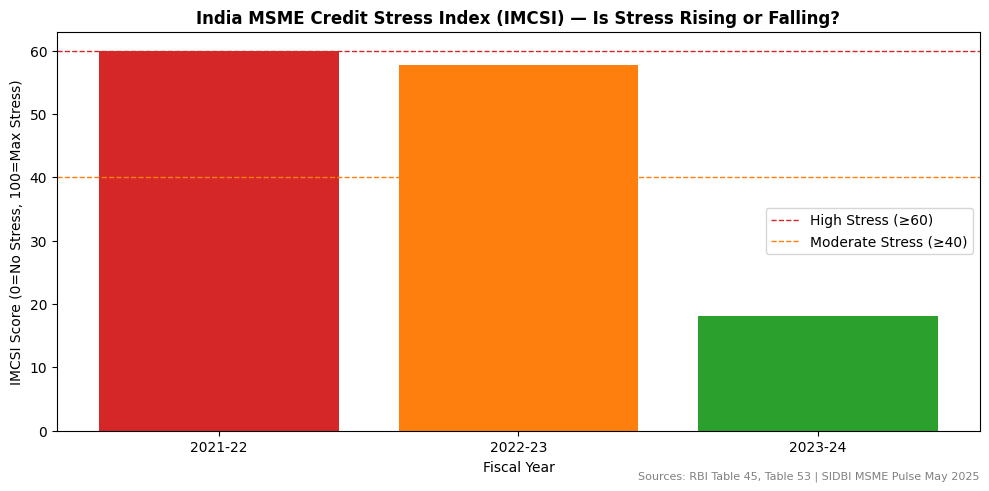

Saved: output/charts/07_imcsi_final.png


In [6]:
# ── Cell 6: IMCSI Visualization ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#d62728' if s == 'High Stress'
          else '#ff7f0e' if s == 'Moderate Stress'
          else '#2ca02c'
          for s in df_master['stress_band']]

ax.bar(df_master['fiscal_year'], df_master['IMCSI'], color=colors)
ax.axhline(60, color='#d62728', linewidth=1, linestyle='--', label='High Stress (≥60)')
ax.axhline(40, color='#ff7f0e', linewidth=1, linestyle='--', label='Moderate Stress (≥40)')

ax.set_title('India MSME Credit Stress Index (IMCSI) — Is Stress Rising or Falling?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('IMCSI Score (0=No Stress, 100=Max Stress)')
ax.legend()
ax.annotate('Sources: RBI Table 45, Table 53 | SIDBI MSME Pulse May 2025',
            xy=(1, -0.12), xycoords='axes fraction',
            ha='right', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('../output/charts/07_imcsi_final.png', dpi=150)
plt.show()
print("Saved: output/charts/07_imcsi_final.png")